In [1]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

from sklearn.cluster import (
    KMeans,
    AgglomerativeClustering,
    DBSCAN
)

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)


# ============================================================
# 2. LOAD BUILT-IN DATASET
# ============================================================

iris = load_iris()

X = iris.data
feature_names = iris.feature_names

print("Dataset Shape:", X.shape)
print("Features:", feature_names)


# ============================================================
# 3. SCALE DATA
# ============================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)



Dataset Shape: (150, 4)
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [2]:
models = {

    "K-Means": KMeans(
        n_clusters=3,
        random_state=42,
        n_init=10
    ),

    "Agglomerative": AgglomerativeClustering(
        n_clusters=3,
        linkage="ward"
    ),

    "DBSCAN": DBSCAN(
        eps=0.8,
        min_samples=5
    )
}


# ============================================================
# 5. TRAIN ALL MODELS + PERFORMANCE
# ============================================================

results = []

labels_dict = {}

for name, model in models.items():

    labels = model.fit_predict(X_scaled)

    labels_dict[name] = labels

    # Remove noise for DBSCAN evaluation
    mask = labels != -1

    X_eval = X_scaled[mask]
    labels_eval = labels[mask]

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    noise_points = np.sum(labels == -1)

    # Metrics require at least 2 clusters
    if n_clusters >= 2:

        silhouette = silhouette_score(
            X_eval,
            labels_eval
        )

        davies_bouldin = davies_bouldin_score(
            X_eval,
            labels_eval
        )

        calinski = calinski_harabasz_score(
            X_eval,
            labels_eval
        )

    else:

        silhouette = np.nan
        davies_bouldin = np.nan
        calinski = np.nan

    results.append({

        "Model": name,
        "Clusters": n_clusters,
        "Noise Points": noise_points,
        "Silhouette Score": silhouette,
        "Davies-Bouldin Score": davies_bouldin,
        "Calinski-Harabasz Score": calinski

    })



results_df = pd.DataFrame(results)

print("\nPerformance Comparison:")
print(results_df)




Performance Comparison:
           Model  Clusters  Noise Points  Silhouette Score  \
0        K-Means         3             0          0.459948   
1  Agglomerative         3             0          0.446689   
2         DBSCAN         2             4          0.597941   

   Davies-Bouldin Score  Calinski-Harabasz Score  
0              0.833595               241.904402  
1              0.803467               222.719164  
2              0.568802               277.650960  


In [3]:
results_df["Silhouette Rank"] = (
    results_df["Silhouette Score"]
    .rank(ascending=False)
)

results_df["DB Rank"] = (
    results_df["Davies-Bouldin Score"]
    .rank(ascending=True)
)

results_df["CH Rank"] = (
    results_df["Calinski-Harabasz Score"]
    .rank(ascending=False)
)

results_df["Total Rank"] = (
    results_df["Silhouette Rank"]
    + results_df["DB Rank"]
    + results_df["CH Rank"]
)

results_df = results_df.sort_values(
    "Total Rank"
)

print("\nFinal Ranking:")
print(results_df)


# ============================================================
# 8. BEST MODEL
# ============================================================

best_model = results_df.iloc[0]["Model"]

print("\nBest Clustering Model:", best_model)






Final Ranking:
           Model  Clusters  Noise Points  Silhouette Score  \
2         DBSCAN         2             4          0.597941   
0        K-Means         3             0          0.459948   
1  Agglomerative         3             0          0.446689   

   Davies-Bouldin Score  Calinski-Harabasz Score  Silhouette Rank  DB Rank  \
2              0.568802               277.650960              1.0      1.0   
0              0.833595               241.904402              2.0      3.0   
1              0.803467               222.719164              3.0      2.0   

   CH Rank  Total Rank  
2      1.0         3.0  
0      2.0         7.0  
1      3.0         8.0  

Best Clustering Model: DBSCAN


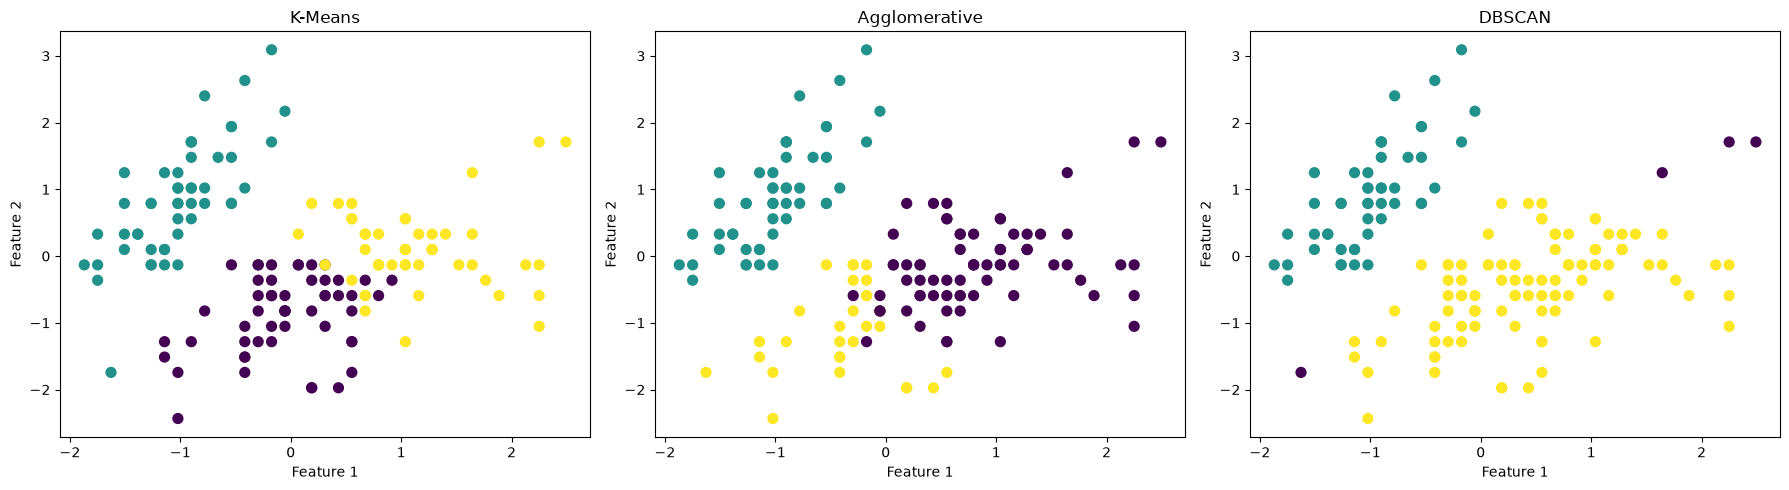

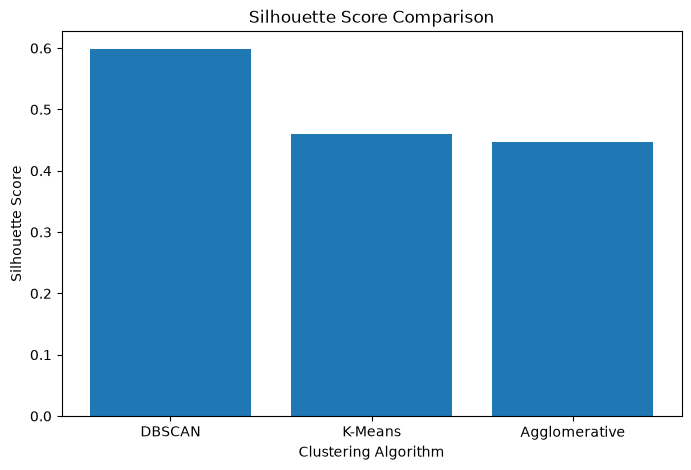

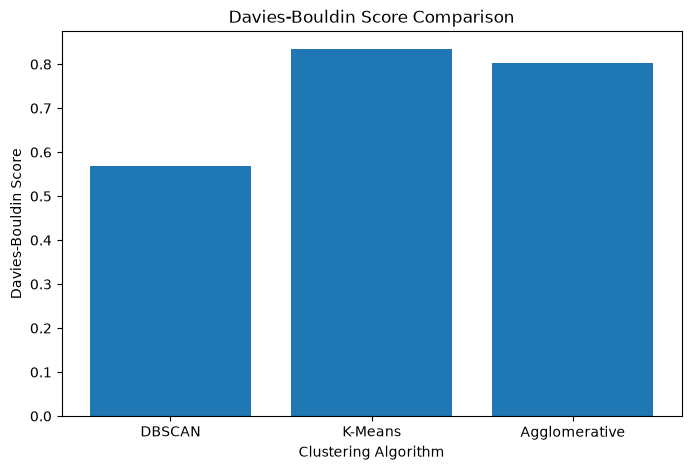

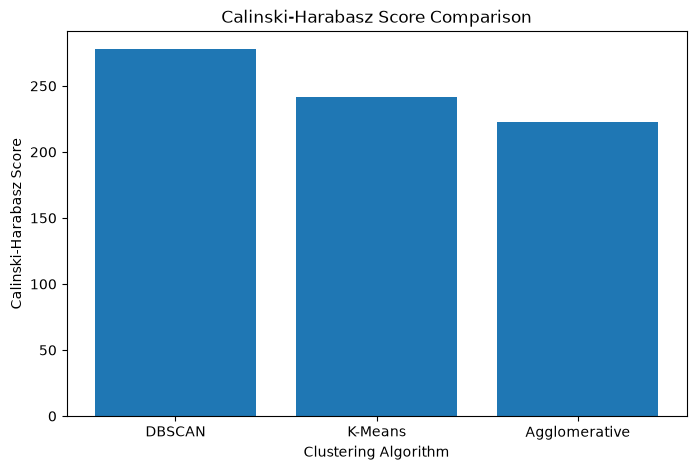


================ FINAL SUMMARY ================

           Model  Clusters  Noise Points  Silhouette Score  \
2         DBSCAN         2             4          0.597941   
0        K-Means         3             0          0.459948   
1  Agglomerative         3             0          0.446689   

   Davies-Bouldin Score  Calinski-Harabasz Score  Total Rank  
2              0.568802               277.650960         3.0  
0              0.833595               241.904402         7.0  
1              0.803467               222.719164         8.0  

Best Model: DBSCAN


In [4]:
# ============================================================
# 9. VISUALIZE ALL 3 MODELS
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5)
)

for ax, (name, labels) in zip(
    axes,
    labels_dict.items()
):

    ax.scatter(
        X_scaled[:, 0],
        X_scaled[:, 1],
        c=labels,
        s=50
    )

    ax.set_title(name)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")

plt.tight_layout()
plt.show()


# ============================================================
# 10. SILHOUETTE SCORE COMPARISON
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(
    results_df["Model"],
    results_df["Silhouette Score"]
)

plt.xlabel("Clustering Algorithm")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score Comparison")

plt.show()


# ============================================================
# 11. DAVIES-BOULDIN SCORE COMPARISON
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(
    results_df["Model"],
    results_df["Davies-Bouldin Score"]
)

plt.xlabel("Clustering Algorithm")
plt.ylabel("Davies-Bouldin Score")
plt.title("Davies-Bouldin Score Comparison")

plt.show()


# ============================================================
# 12. CALINSKI-HARABASZ SCORE COMPARISON
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(
    results_df["Model"],
    results_df["Calinski-Harabasz Score"]
)

plt.xlabel("Clustering Algorithm")
plt.ylabel("Calinski-Harabasz Score")
plt.title("Calinski-Harabasz Score Comparison")

plt.show()


# ============================================================
# 13. FINAL SUMMARY
# ============================================================

print("\n================ FINAL SUMMARY ================\n")

print(
    results_df[
        [
            "Model",
            "Clusters",
            "Noise Points",
            "Silhouette Score",
            "Davies-Bouldin Score",
            "Calinski-Harabasz Score",
            "Total Rank"
        ]
    ]
)

print("\nBest Model:", best_model)